In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import random

import warnings
warnings.filterwarnings('ignore')


In [ ]:
import glob

In [ ]:
!unzip /content/face_mask_dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: face_mask_dataset/train/without_mask/without_mask_3347.jpg  
  inflating: face_mask_dataset/train/without_mask/without_mask_3348.jpg  
  inflating: face_mask_dataset/train/without_mask/without_mask_3349.jpg  
  inflating: face_mask_dataset/train/without_mask/without_mask_335.jpg  
  inflating: face_mask_dataset/train/without_mask/without_mask_3350.jpg  
  inflating: face_mask_dataset/train/without_mask/without_mask_3351.jpg  
  inflating: face_mask_dataset/train/without_mask/without_mask_3354.jpg  
  inflating: face_mask_dataset/train/without_mask/without_mask_3356.jpg  
  inflating: face_mask_dataset/train/without_mask/without_mask_3357.jpg  
  inflating: face_mask_dataset/train/without_mask/without_mask_3358.jpg  
  inflating: face_mask_dataset/train/without_mask/without_mask_3359.jpg  
  inflating: face_mask_dataset/train/without_mask/without_mask_336.jpg  
  inflating: face_mask_dataset/train/without_mask/without_mask_

In [ ]:
class_dirs=os.listdir("/content/face_mask_dataset/train")

In [ ]:
image_dict = {} # dict to store an image array for every class
count_dict = {} # dict to store count of files for every class

for cls in class_dirs:

    file_paths = glob.glob(f'/content/face_mask_dataset/train/{cls}/*')
    count_dict[cls] = len(file_paths)
    image_path = random.choice(file_paths)

    # load image using keras utility function and save it in image_dict
    image_dict[cls] = tf.keras.utils.load_img(image_path)

In [ ]:
image_dict

{'with_mask': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=327x433>,
 'without_mask': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=197x255>}

In [ ]:
count_dict

{'with_mask': 2607, 'without_mask': 2679}

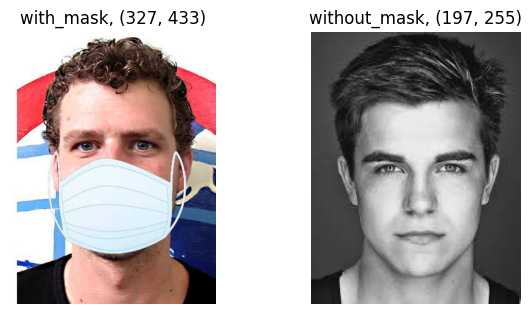

In [ ]:
plt.figure(figsize=(15, 12))

for i, (cls,img) in enumerate(image_dict.items()):
    # create a subplot axis
    ax = plt.subplot(3, 4, i + 1)            # assuming the images to be at most 12
    plt.imshow(img)
    plt.title(f'{cls}, {img.size}')
    plt.axis("off")         # remove x and y label to make the code cleaner

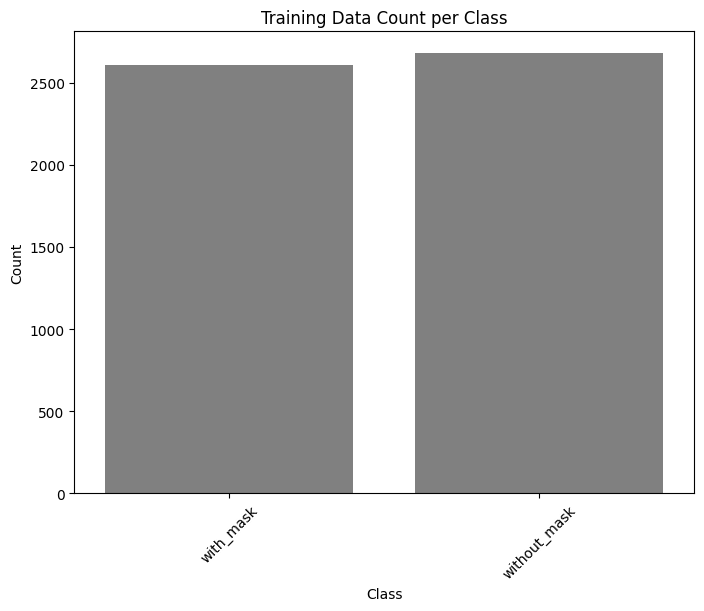

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x=list(count_dict.keys()), y=list(count_dict.values()), color='grey')
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Training Data Count per Class")
plt.xticks(rotation=45)
plt.show()

In [ ]:

print('\nLoading Train Data...')
train_data = tf.keras.utils.image_dataset_from_directory(
    "/content/face_mask_dataset/train", shuffle = True,
)

print('\nLoading Validation Data...')
val_data = tf.keras.utils.image_dataset_from_directory(
    "/content/face_mask_dataset/val", shuffle = False,
)

print('\nLoading Test Data...')
test_data = tf.keras.utils.image_dataset_from_directory(
    "/content/face_mask_dataset/test", shuffle = False,
)


Loading Train Data...
Found 5287 files belonging to 2 classes.

Loading Validation Data...
Found 1510 files belonging to 2 classes.

Loading Test Data...
Found 757 files belonging to 2 classes.


In [ ]:
for i,j in train_data:
  print(i.shape)
  print(j.shape)

  break

(32, 256, 256, 3)
(32,)


In [ ]:
len(train_data)

166

In [ ]:
height, width = 128, 128

In [ ]:
data_preprocess = keras.Sequential(
                        name="data_preprocess",
                        layers=[
                            layers.Resizing(height, width),   # Shape Preprocessing
                            layers.Rescaling(1.0/255),        # Value Preprocessing
                        ]
                  )

In [ ]:
# Perform Data Processing on the train, val, test dataset
train_ds = train_data.map(lambda x, y: (data_preprocess(x), y))
val_ds = val_data.map(lambda x, y: (data_preprocess(x), y))
test_ds = test_data.map(lambda x, y: (data_preprocess(x), y))

# **Building a Neural Network**

In [ ]:
num_classes = 1
hidden_size_1 = 1024
hidden_size_2 = 256

model = keras.Sequential(
                name="ANN_Model",
                layers=[
                    layers.Flatten(input_shape=(height, width, 3)),          # alternatively, input_shape=next(iter(train_ds))[0].shape[1:]
                    layers.Dense(units=hidden_size_1, activation='relu'),
                    layers.Dense(units=hidden_size_2, activation='relu'),
                    layers.Dense(units=num_classes, activation='softmax'),
                ]
            )

In [ ]:
def model1(height=128, width=128):
    num_classes = 1
    hidden_size = 256

    model = keras.Sequential(
        name="model1",
        layers=[

            layers.Conv2D(filters=16, kernel_size=3,  activation='relu', input_shape=(height, width, 3)),
            layers.MaxPooling2D(),

            layers.Conv2D(filters=32, kernel_size=3,  activation='relu'),
            layers.MaxPooling2D(),

            layers.Conv2D(filters=64, kernel_size=3, activation='relu'),
            layers.MaxPooling2D(),

            layers.Conv2D(filters=128, kernel_size=3,  activation='relu'),
            layers.MaxPooling2D(),

            layers.Conv2D(filters=256, kernel_size=3, activation='relu'),
            layers.GlobalAveragePooling2D(),

            layers.Dense(units=hidden_size, activation='relu'),
            layers.Dense(units=1, activation='sigmoid')
        ]
    )
    return model

In [ ]:
model = model1()

In [ ]:
model.summary()

Model: "model1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,657 (1.75 MB)

 Trainable params: 458,657 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
ModelCheckpoint = keras.callbacks.ModelCheckpoint(filepath='tf_model.weights.h5', save_weights_only=True,
                                                  monitor='val_accuracy', mode='max', save_best_only=True),

In [ ]:
model_fit = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[ModelCheckpoint])


Epoch 1/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - accuracy: 0.8067 - loss: 0.4009 - val_accuracy: 0.8993 - val_loss: 0.2654
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.9228 - loss: 0.2099 - val_accuracy: 0.9212 - val_loss: 0.2149
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.9363 - loss: 0.1688 - val_accuracy: 0.9079 - val_loss: 0.2494
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.9438 - loss: 0.1550 - val_accuracy: 0.9450 - val_loss: 0.1565
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.9550 - loss: 0.1317 - val_accuracy: 0.9477 - val_loss: 0.1598
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.9540 - loss: 0.1253 - val_accuracy: 0.9530 - val_loss: 0.1436
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.9561 - loss: 0.1155 - val_accuracy: 0.9397 - val_loss: 0.1570
Epoch 8/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.9643 - loss: 0.1001 - v

In [ ]:
def acc_plot(model):
    params_cnn = model.params
    history_cnn = model.history

    plt.plot(range(0,params_cnn['epochs']), history_cnn['accuracy'], label='Training', color='r')
    plt.plot(range(0,params_cnn['epochs']), history_cnn['val_accuracy'], label='Validation', color='b')
    plt.title('Model1 Accuracy Plot', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()

    plt.show()

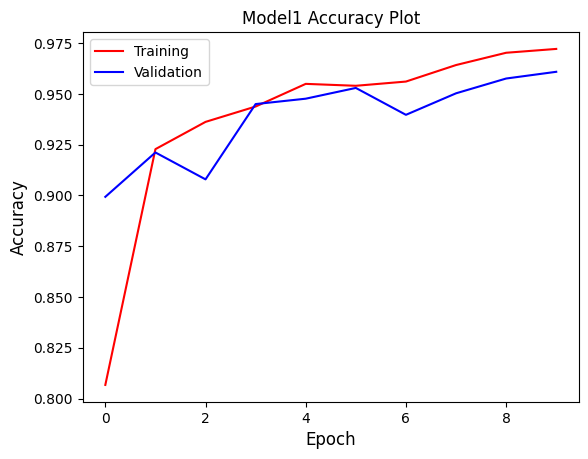

In [ ]:
acc_plot(model_fit)

In [ ]:
model_fit = model.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=[ModelCheckpoint])

Epoch 1/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.9697 - loss: 0.0811 - val_accuracy: 0.9483 - val_loss: 0.1518
Epoch 2/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.9718 - loss: 0.0794 - val_accuracy: 0.9636 - val_loss: 0.1234
Epoch 3/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.9818 - loss: 0.0535 - val_accuracy: 0.9629 - val_loss: 0.1239
Epoch 4/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.9830 - loss: 0.0481 - val_accuracy: 0.9636 - val_loss: 0.1305
Epoch 5/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.9873 - loss: 0.0392 - val_accuracy: 0.9543 - val_loss: 0.1648
Epoch 6/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.9847 - loss: 0.0454 - val_accuracy: 0.9536 - val_loss: 0.1349
Epoch 7/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9830 - loss: 0.0491 - val_accuracy: 0.9497 - val_loss: 0.1757
Epoch 8/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.9862 - loss: 0.0424 - v

In [ ]:
train_score = model.evaluate(train_ds)
val_score = model.evaluate(val_ds)
test_score = model.evaluate(test_ds)

166/166 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 1.0000 - loss: 1.7181e-06
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9722 - loss: 0.2849
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9709 - loss: 0.2512


In [ ]:
def load_and_preprocess_image(path):
    img = tf.keras.preprocessing.image.load_img(path)
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = tf.expand_dims(img, axis=0)
    img = img / 255.0
    return img

In [ ]:
classnames=train_data.class_names

In [ ]:
image_path = '/content/face_mask_dataset/test/with_mask/with_mask_1010.jpg'
preprocessed_img = load_and_preprocess_image(image_path)
prediction = model.predict(preprocessed_img)
threshold=0.5
if prediction >= threshold:
  print(classnames[1])
else:
  print(classnames[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
with_mask


In [ ]:
image_path = '/content/face_mask_dataset/test/without_mask/without_mask_104.jpg'
preprocessed_img = load_and_preprocess_image(image_path)
prediction = model.predict(preprocessed_img)
threshold=0.5
if prediction >= threshold:
  print(classnames[1])
else:
  print(classnames[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step
without_mask


In [ ]:
image_path = '/content/face_mask1.jpg'
preprocessed_img = load_and_preprocess_image(image_path)
prediction = model.predict(preprocessed_img)
threshold=0.5
if prediction >= threshold:
  print(classnames[1])
else:
  print(classnames[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 730ms/step
with_mask


In [ ]:
image_path = '/content/face_mask3.jpg'
preprocessed_img = load_and_preprocess_image(image_path)
prediction = model.predict(preprocessed_img)
threshold=0.5
if prediction >= threshold:
  print(classnames[1])
else:
  print(classnames[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step
without_mask


In [ ]:
model.save("mustafa_cnn_model.h5")

In [ ]:
#import random

#idx = random.randint(0, len(test_ds)-1)
#img=test_ds[idx]
#plt.imshow(img)
#pred = model.predict(load_and_preprocess_image(test_ds[idx]))

#print("Predicted: " + ("Without Mask" if pred > 0.5 else "With Mask"))
